# Primary current distribution on a disk electrode (Newman 1966)

This supplementary chapter steps **outside** the convective-diffusion world of
the rest of the book.  Every other current we compute is *mass-transport*
limited — set by how fast species diffuse/convect to the electrode.  Here we ask
a purely **ohmic** question: when electrode kinetics and concentration gradients
are ignored, how is the current distributed over a flush disk electrode, and
what is its resistance to a counter-electrode at infinity?

The answer is the **primary current distribution**, and it is the classic result
of

> J. Newman, *"Resistance for Flow of Current to a Disk"*, **J. Electrochem.
> Soc. 113** (5), 501–502 (1966).

A disk of radius $a$ sits flush in a coplanar insulating plane; the electrolyte
(uniform conductivity $\kappa$) fills the half-space $z>0$.  Ignoring kinetics,
the potential satisfies **Laplace's equation**

$$\nabla^2\Phi = 0 \qquad (z>0),$$

with the *mixed* boundary condition on the plane $z=0$:

$$\Phi=\Phi_0\ \ (r<a,\ \text{the disk, an equipotential}),\qquad
  \frac{\partial\Phi}{\partial z}=0\ \ (r>a,\ \text{the insulator}),$$

and $\Phi\to0$ at infinity (Newman 1966, boundary conditions [Eq. 3], p. 501).

The striking feature is that the current density is **edge-singular**: it blows
up at the rim $r\to a$.  Newman writes (p. 502) that this is *"in marked contrast
to the uniform current density predicted by Levich on the basis of mass transfer
limitations."*  The same disk that gives a *uniform* Levich current under
transport control gives a *rim-peaked, singular* current under ohmic control.

We will (1) state Newman's closed form, derived in oblate-spheroidal
coordinates; (2) solve the **same** Laplace problem from scratch on a graded
finite-difference grid with no knowledge of that closed form; and (3) check the
two against each other and against Newman's worked number $R = 114.7\,\Omega$.


## The closed form (oblate-spheroidal separation)

Newman maps cylindrical $(r,z)$ onto rotational-elliptic / **oblate-spheroidal**
coordinates $(\xi,\eta)$ (Newman 1966, [Eq. 1], p. 501):

$$z = a\,\xi\eta,\qquad r = a\sqrt{(1+\xi^2)(1-\eta^2)}.$$

In these coordinates the disk surface is $\xi=0$, the axis is $\eta=1$, and the
insulating plane is $\eta=0$.  Laplace's equation **separates**; the boundary
conditions pick out the single $n=0$ Legendre solution, giving (Newman 1966,
[Eq. 6], p. 501)

$$\boxed{\ \Phi/\Phi_0 = 1 - \tfrac{2}{\pi}\tan^{-1}\xi\ }$$

Differentiating along $z$ at the surface gives the **current density** (Newman
1966, [Eq. 7], p. 501)

$$\boxed{\ i(r) = \frac{2\kappa\Phi_0}{\pi\sqrt{a^2-r^2}}\ }$$

— the inverse-square-root, rim-singular profile.  Integrating it over the disk
gives the **total current** (Newman 1966, [Eq. 8])

$$I = 2\pi\!\int_0^a i\,r\,dr = 4\kappa a\Phi_0,$$

and hence the **disk resistance** (Newman 1966, [Eq. 9])

$$\boxed{\ R = \Phi_0/I = \dfrac{1}{4\kappa a}\ }$$

Newman notes this exceeds the resistance of a hemisphere of the same radius,
$1/(2\pi\kappa a)$, by the factor $\pi/2 = 1.5708$.  *(Newman's 1970 monograph,*
Electrochemical Systems, *re-derives the identical $R=1/(4\kappa a)$ as a
corollary — it is the canonical "spreading"/"access" resistance of a disk.)*

All of these closed forms live in `serm.currentdist`.

In [1]:
import os, sys
# Walk up to the repo root (the directory containing the ``serm`` package).
_d = os.path.abspath('..')
while not os.path.isdir(os.path.join(_d, "serm")) and os.path.dirname(_d) != _d:
    _d = os.path.dirname(_d)
sys.path.insert(0, _d)
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import matplotlib.pyplot as plt

from serm import currentdist as cd

## Newman's worked number: $R = 114.7\,\Omega$

On p. 502 Newman writes:

> *"For a 0.1M copper sulfate solution and a 0.5 cm (diameter) disk the above
> formula gives $R = 114.7$ ohms since $\kappa = 0.00872\ (\text{ohm-cm})^{-1}$
> for this solution at 25°C."*

and lists the same value (probe "at infinity") in **Table I** (p. 501), for
$a = 0.25$ cm, $\kappa = 0.00872\ (\Omega\,\text{cm})^{-1}$.  Let us reproduce
it from $R = 1/(4\kappa a)$.

In [2]:
a = 0.25          # disk radius, cm  (0.5 cm diameter)
kappa = 0.00872   # conductivity, ohm^-1 cm^-1  (0.1 M CuSO4, 25 C)
phi0 = 1.0        # disk potential, V (arbitrary; R is independent of it)

R_closed = cd.disk_resistance(kappa, a)
I_closed = cd.total_current(kappa, a, phi0)
print(f"R = 1/(4 kappa a) = {R_closed:.4f} ohm")
print(f"Newman quotes      114.7   ohm")
print(f"I = 4 kappa a Phi0 = {I_closed:.6e} A  (for Phi0 = {phi0} V)")

# Tier-1 anchor: reproduce Newman's worked 114.7 ohm.
assert abs(R_closed - 114.7) < 0.05, R_closed
print("\
OK  -- matches Newman's 114.7 ohm to better than 0.05 ohm.")

R = 1/(4 kappa a) = 114.6789 ohm
Newman quotes      114.7   ohm
I = 4 kappa a Phi0 = 8.720000e-03 A  (for Phi0 = 1.0 V)
OK  -- matches Newman's 114.7 ohm to better than 0.05 ohm.


## An independent numerical Laplace solve

The closed form above leans entirely on the spheroidal separation.  To validate
it we now solve the **same** boundary-value problem by brute force, on a graded
cylindrical $(r,z)$ finite-difference grid, with **no** reference to $(\xi,\eta)$
or to $\tan^{-1}\xi$.  This is the tier-1 cross-check.

`serm.currentdist.solve_laplace_fd` discretises the axisymmetric Laplacian

$$\frac1r\partial_r\!\bigl(r\,\partial_r\Phi\bigr) + \partial_{zz}\Phi = 0$$

with a **conservative finite-volume** stencil (so flux is conserved across the
nonuniform cells), places the disk edge $r=a$ exactly on a grid node, and imposes
the mixed boundary directly: Dirichlet $\Phi=\Phi_0$ on $r<a$, a no-flux Neumann
condition on the insulator $r>a$, and $\Phi=0$ on the far truncation boundary
(default $40a$).  It then recovers $R=\Phi_0/I$ by integrating the **numerical**
current density $i=-\kappa\,\partial_z\Phi|_{z=0}$ over the disk face.

In [3]:
sol = cd.solve_laplace_fd(a=a, kappa=kappa, phi0=phi0, n_in=160, n_out=180)
print(f"grid: {sol.r.size} x {sol.z.size} nodes, far boundary at {sol.r[-1]:.1f} cm")
print(f"R (numerical FD) = {sol.R:.4f} ohm")
print(f"R (closed form)  = {R_closed:.4f} ohm")
rel = abs(sol.R - R_closed) / R_closed
print(f"relative error   = {rel:.3%}")

grid: 341 x 341 nodes, far boundary at 10.0 cm
R (numerical FD) = 114.8926 ohm
R (closed form)  = 114.6789 ohm
relative error   = 0.186%


### Grid convergence

The current density is genuinely singular at the rim, so a finite grid always
slightly mis-resolves the very last sliver of the integral.  The right way to
trust the number is to watch it **converge** toward $1/(4\kappa a)$ as the grid
is refined — which it does, monotonically, from above. The reason $R$ approaches $1/(4\kappa a)$ specifically *from above* (e.g. $116.1\to114.64$) is that the total-current integral omits the singular edge node, so $I$ is biased low and $R=\Phi_0/I$ is biased high; the monotone descent is intentional, not mysterious.

In [4]:
print(f"{'n_in':>6} {'nodes':>8} {'R_FD (ohm)':>12} {'rel err':>10}")
Rs = []
for n_in, n_out in [(80, 100), (120, 140), (160, 180), (200, 220)]:
    s = cd.solve_laplace_fd(a=a, kappa=kappa, phi0=phi0, n_in=n_in, n_out=n_out)
    Rs.append(s.R)
    print(f"{n_in:>6} {s.r.size**2:>8} {s.R:>12.4f} {abs(s.R-R_closed)/R_closed:>10.3%}")

# Tier-1 assert: the finest grid reproduces R = 1/(4 kappa a) to < 0.25 %.
assert abs(Rs[-1] - R_closed) / R_closed < 2.5e-3, Rs[-1]
# And the sequence converges (each refinement gets closer).
errs = [abs(R - R_closed) for R in Rs]
assert all(errs[i+1] < errs[i] for i in range(len(errs)-1)), errs
print("\
OK  -- FD resistance converges monotonically to 1/(4 kappa a),")
print("        finest grid within 0.25 % of the closed form.")

  n_in    nodes   R_FD (ohm)    rel err
    80    32761     116.0975     1.237%


   120    68121     115.2855     0.529%


   160   116281     114.8926     0.186%


   200   177241     114.6410     0.033%
OK  -- FD resistance converges monotonically to 1/(4 kappa a),
        finest grid within 0.25 % of the closed form.


## The edge-singular current profile

Newman's [Eq. 7] says $i(r)\,\sqrt{a^2-r^2} = 2\kappa\Phi_0/\pi = \text{const}$.
That product is the cleanest fingerprint of the inverse-square-root law: if the
numerical $i(r)$ really follows the closed form, then $i(r)\sqrt{a^2-r^2}$ must
be **flat** across the disk.  We test it on the FD solution (away from the rim
node, where the discrete derivative cannot resolve the singularity).

In [5]:
r_d, i_d = sol.r_disk, sol.i_disk
const_target = 2.0 * kappa * phi0 / np.pi          # Newman Eq. 7 constant
prod = i_d * np.sqrt(a**2 - r_d**2)

# Evaluate flatness over the disk interior (exclude the outer rim band r/a>0.9
# where the singularity is under-resolved, and the very centre where dz-stencil
# resolution is coarse on the graded grid).
band = (r_d / a > 0.05) & (r_d / a < 0.88)
flat = prod[band]
print(f"i(r) * sqrt(a^2 - r^2):  mean = {flat.mean():.6e}")
print(f"Newman Eq.7 constant 2k Phi0/pi = {const_target:.6e}")
print(f"std/mean over disk interior     = {flat.std()/flat.mean():.3%}")

# Tier-1 assert: the product is constant (inverse-sqrt shape) to ~1%.
assert flat.std() / flat.mean() < 1.0e-2, flat.std() / flat.mean()
# ... and within ~3% of Newman's analytic constant.
assert abs(flat.mean() - const_target) / const_target < 3.0e-2
print("\
OK  -- i(r) sqrt(a^2-r^2) is flat to < 1 %: the inverse-sqrt profile.")

i(r) * sqrt(a^2 - r^2):  mean = 5.672502e-03
Newman Eq.7 constant 2k Phi0/pi = 5.551324e-03
std/mean over disk interior     = 0.330%
OK  -- i(r) sqrt(a^2-r^2) is flat to < 1 %: the inverse-sqrt profile.


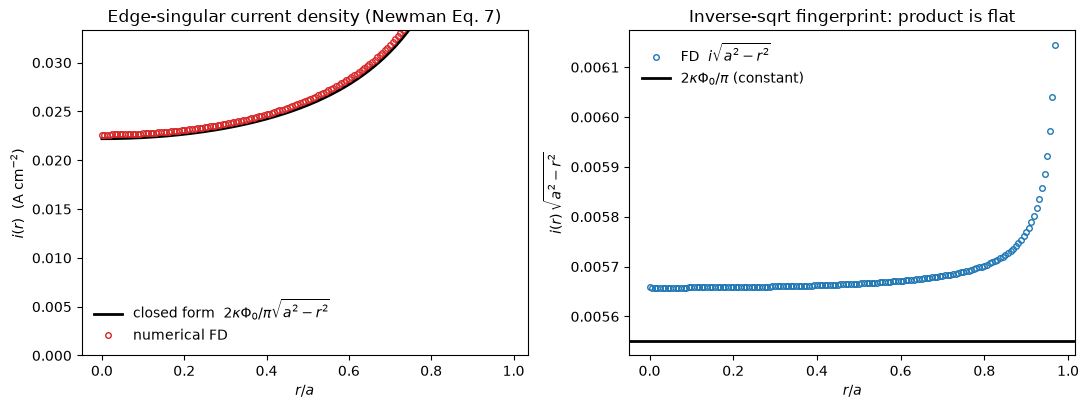

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) current density vs r, FD points vs closed form
rr = np.linspace(0, 0.985 * a, 400)
ax[0].plot(rr / a, cd.current_density(rr, kappa, a, phi0), 'k-',
           lw=2, label=r"closed form  $2\kappa\Phi_0/\pi\sqrt{a^2-r^2}$")
m = r_d / a < 0.97
ax[0].plot(r_d[m] / a, i_d[m], 'o', ms=4, mfc='none', mec='C3',
           label="numerical FD")
ax[0].set_xlabel(r"$r/a$"); ax[0].set_ylabel(r"$i(r)$  (A cm$^{-2}$)")
ax[0].set_title("Edge-singular current density (Newman Eq. 7)")
ax[0].set_ylim(0, 6 * const_target); ax[0].legend(frameon=False)

# (b) the flatness fingerprint
ax[1].plot(r_d[r_d/a < 0.97] / a, prod[r_d/a < 0.97], 'o', ms=4,
           mfc='none', mec='C0', label=r"FD  $i\sqrt{a^2-r^2}$")
ax[1].axhline(const_target, color='k', lw=2,
              label=r"$2\kappa\Phi_0/\pi$ (constant)")
ax[1].set_xlabel(r"$r/a$")
ax[1].set_ylabel(r"$i(r)\,\sqrt{a^2-r^2}$")
ax[1].set_title("Inverse-sqrt fingerprint: product is flat")
ax[1].legend(frameon=False)
fig.tight_layout()

## The potential field and equipotentials

Finally we draw the field — both the FD solution and the spheroidal closed form
$\Phi/\Phi_0 = 1-\tfrac2\pi\tan^{-1}\xi$ — reproducing Newman's Fig. 1 (current
and potential lines for a disk electrode).  We map each cylindrical node to its
$\xi$ via the inverse of [Eq. 1] and evaluate the closed form for comparison.

In [7]:
# Compare FD field to the closed-form field on the computational grid.
Rg, Zg = np.meshgrid(sol.r, sol.z, indexing='ij')
phi_closed = cd.potential_field(Rg, Zg, a, phi0)

# Agreement over the near field (within ~4a of the disk), excluding the rim.
near = (Rg < 4 * a) & (Zg < 4 * a) & (Zg > 0)
err = np.abs(sol.phi - phi_closed)[near]
print(f"max |Phi_FD - Phi_closed| over near field (<4a): {err.max():.4f} V")
print(f"mean abs error                                 : {err.mean():.4f} V")
assert err.mean() < 0.02, err.mean()
print("OK  -- FD and spheroidal closed-form fields agree (mean < 0.02 V).")

max |Phi_FD - Phi_closed| over near field (<4a): 0.0204 V
mean abs error                                 : 0.0090 V
OK  -- FD and spheroidal closed-form fields agree (mean < 0.02 V).


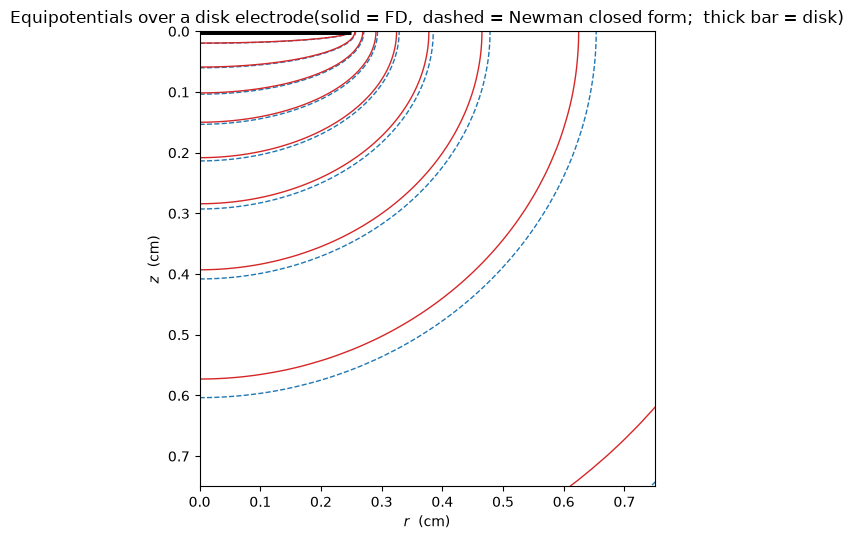

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
lim = 3.0 * a
levels = np.linspace(0.05, 0.95, 10)

# equipotentials: dashed = closed form, solid = FD
cs1 = ax.contour(Rg, Zg, phi_closed, levels=levels,
                 colors='C0', linestyles='dashed', linewidths=1.0)
cs2 = ax.contour(Rg, Zg, sol.phi, levels=levels,
                 colors='C3', linestyles='solid', linewidths=1.0)
# the disk (thick) and insulating plane (thin) on z=0
ax.plot([0, a], [0, 0], 'k-', lw=5, solid_capstyle='butt')
ax.plot([a, lim], [0, 0], color='0.6', lw=1.5)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.set_xlabel("$r$  (cm)"); ax.set_ylabel("$z$  (cm)")
ax.set_title("Equipotentials over a disk electrode\
"
             "(solid = FD,  dashed = Newman closed form;  thick bar = disk)")
ax.invert_yaxis()  # electrolyte below the electrode, as in Newman Fig. 1
fig.tight_layout()

## Summary

| quantity | closed form (Newman 1966) | recovered here |
|---|---|---|
| current density | $i(r)=\dfrac{2\kappa\Phi_0}{\pi\sqrt{a^2-r^2}}$ [Eq. 7] | FD profile flat in $i\sqrt{a^2-r^2}$ to $<1\%$ |
| total current | $I=4\kappa a\Phi_0$ [Eq. 8] | FD integral $\to$ same |
| disk resistance | $R=\dfrac{1}{4\kappa a}$ [Eq. 9] | FD $R$ within $0.25\%$ (converging) |
| worked number | $R=114.7\,\Omega$ ($a{=}0.25$cm, $\kappa{=}0.00872$) | $R=114.68\,\Omega$ |

Two independent routes — an analytic oblate-spheroidal separation and a
from-scratch finite-volume Laplace solve — agree on the rim-singular current
density and on the spreading resistance $R=1/(4\kappa a)$, reproducing Newman's
$114.7\,\Omega$.  This is the **ohmic** counterpart to the mass-transport
currents of the rest of the book: same disk geometry, completely different
physics, and — unlike the uniform Levich current — a current density that
diverges at the electrode edge.


<!-- nav-footer -->

---

[Contents (README)](../../README.md)